In [2]:
#This code mostly follows ModelBuildExample.ipynb, written by Professor Schuckers with different decision made based on the dataset

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
import pylab as py 
import numpy as np
from sklearn import tree
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
# here are some of the tools we will use for our analyses
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import PredictionErrorDisplay

In [3]:
hlt = pd.read_csv('NPA_HLT.csv', encoding='utf-8-sig')

hlt

,OBJECTID,NPAs_NPA,NPAs_LandArea,NPA_Lookup__NPA,NPA_Lookup__Access_Score,NPA_Lookup__Jobs_Accessible_by_,NPA_Lookup__Jobs_Accessible_by1,NPA_Lookup__Change_Score,NPA_Lookup__Median_Household_In,NPA_Lookup__Median_Household__1,...,CreationDate,Creator,EditDate,Editor,NPA_Lookup_pvrty_median_rate,NPA_Lookup_pvrty_75_rate,GlobalID,Vintage,ShapeSTArea,ShapeSTLength
0,24922,188,365,188.0,2.673579,973881.0,0.0,0.96,93654,90.066225,...,NaN,cmesimer_charlotte,NaN,cmesimer_charlotte,11,27,{14EE3F0C-0A5D-414A-82B4-755597275ED4},August 2019,1.588800e+07,18597.621766
1,24923,131,270,131.0,2.803145,1032030.0,0.0,6.99,57741,39.514349,...,NaN,cmesimer_charlotte,NaN,cmesimer_charlotte,11,22,{41FDC6F3-1FC2-4921-AA47-EB7F9E8257CD},February 2021,1.177141e+07,14512.424634
2,24924,64,381,64.0,3.263847,1176104.0,3775.0,4.86,31604,13.907285,...,NaN,cmesimer_charlotte,NaN,cmesimer_charlotte,11,22,{B74B263D-4D16-488A-9C7F-69A94685F5A8},December 2020,1.661415e+07,18344.971871
3,24925,326,152,326.0,6.980000,1248511.0,196575.0,9.82,43984,17.600000,...,NaN,NaN,NaN,NaN,17,29,{81E8B7FD-9AD8-4295-AAE1-C31A361ABC1D},July 2024,6.618133e+06,13364.839780
4,24926,336,1522,336.0,3.557770,1230696.0,11700.0,6.20,61689,63.134658,...,NaN,cmesimer_charlotte,NaN,cmesimer_charlotte,11,22,{7690EB7E-A2B2-4D23-BF81-7925143C2324},February 2021,6.630655e+07,32627.422048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2302,27224,304,67,304.0,5.830000,1162519.0,146422.0,2.43,30938,36.743468,...,NaN,NaN,NaN,NaN,16,26,{BA34F85E-A8C8-4BBF-B2C4-3DD24549DBE8},June 2022,2.898428e+06,8243.562640
2303,27225,100,725,100.0,3.111765,1111120.0,5104.0,8.17,33931,14.790287,...,NaN,cmesimer_charlotte,NaN,cmesimer_charlotte,11,22,{30F28A01-B288-4502-AE4E-824779EAD0FF},February 2021,3.159296e+07,40530.595800
2304,27226,172,944,172.0,3.020040,1069479.0,4688.0,1.90,132700,91.832230,...,NaN,cmesimer_charlotte,NaN,cmesimer_charlotte,11,27,{9E39D8E5-0A7C-4E1B-BEC1-90993F270BE2},August 2019,4.109948e+07,33032.095399
2305,27227,328,735,328.0,5.194185,1241316.0,99679.0,5.31,73269,49.006623,...,NaN,cmesimer_charlotte,NaN,cmesimer_charlotte,11,27,{8A084A3A-5D61-40AF-9BB9-D20BA37BC6EF},August 2019,3.199526e+07,26487.981883


In [4]:
newhlt = hlt[["NPAs_NPA", "NPA_Lookup__Median_Sales_Price", "NPA_Lookup__Jobs_Accessible_by_", "NPA_Lookup__Median_Household_In"]]
newhlt

,NPAs_NPA,NPA_Lookup__Median_Sales_Price,NPA_Lookup__Jobs_Accessible_by_,NPA_Lookup__Median_Household_In
0,188,354750,973881.0,93654
1,131,215000,1032030.0,57741
2,64,189500,1176104.0,31604
3,326,522500,1248511.0,43984
4,336,240000,1230696.0,61689
...,...,...,...,...
2302,304,0,1162519.0,30938
2303,100,174000,1111120.0,33931
2304,172,419500,1069479.0,132700
2305,328,152500,1241316.0,73269


In [5]:
newhlt = newhlt.groupby('NPAs_NPA')[['NPA_Lookup__Median_Sales_Price','NPA_Lookup__Jobs_Accessible_by_', 'NPA_Lookup__Median_Household_In']].mean().reset_index()
newhlt

,NPAs_NPA,NPA_Lookup__Median_Sales_Price,NPA_Lookup__Jobs_Accessible_by_,NPA_Lookup__Median_Household_In
0,2,424750.0,1179306.8,51095.0
1,3,542600.0,1226974.0,101143.2
2,4,1817800.0,1055251.0,186159.2
3,5,192300.0,1271680.2,29648.0
4,6,361200.0,1271447.6,30749.8
...,...,...,...,...
458,472,273000.0,259901.0,89063.0
459,473,117500.0,553363.0,50953.4
460,474,125000.0,426426.0,49949.8
461,475,172500.0,524313.0,117029.4


In [6]:
newhlt.columns = ['NPA', 'median_sale_price', 'jobs_accessable_by_45_minutes', 'median_household_income']

In [7]:
crm = pd.read_csv('CrimeViolent.csv', encoding='utf-8-sig')

crm

,NPA,2011,2013,2015,2016,2017,2018,2019,2020,2021,...,2011 Raw,2013 Raw,2015 Raw,2016 Raw,2017 Raw,2018 Raw,2019 Raw,2020 Raw,2021 Raw,2022 Raw
0,2,9,7,5,5,5,7,8,9,8,...,19,15,10,11,11,15,18,19,18,24
1,3,2,2,2,4,4,4,3,4,3,...,13,17,17,33,37,38,42,43,40,47
2,4,0,0,1,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,1,0
3,5,22,25,19,20,16,12,26,25,19,...,13,19,14,16,13,9,20,19,15,9
4,6,27,31,24,29,38,28,30,32,28,...,45,55,42,53,71,51,54,57,51,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,472,0,0,0,1,--,3,--,--,--,...,0,0,0,1,0,4,0,0,0,0
455,473,--,2,4,3,1,1,2,0,3,...,0,5,8,6,2,3,4,0,6,0
456,474,2,1,1,5,--,3,--,--,--,...,4,3,2,13,0,8,0,0,0,0
457,475,--,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,3,0


In [8]:
newcrm = crm[["NPA", "2020 Raw"]]

In [9]:
newcrm.columns = ['NPA', 'crime_rate']
newcrm

,NPA,crime_rate
0,2,19
1,3,43
2,4,0
3,5,19
4,6,57
...,...,...
454,472,0
455,473,0
456,474,0
457,475,0


In [10]:
emp = pd.read_csv('Employment.csv', encoding='utf-8-sig')
emp.columns = ['NPA', 'employment_rate']
emp

,NPA,employment_rate
0,2,95.6%
1,3,97.4%
2,4,94.3%
3,5,82.8%
4,6,100%
...,...,...
454,472,100%
455,473,99.8%
456,474,100%
457,475,94%


In [11]:
pop = pd.read_csv('PopulationDensity.csv', encoding='utf-8-sig')

pop

,NPA,2000,2010,2013,2015,2016,2017,2018,2020,2000 Raw,2010 Raw,2013 Raw,2015 Raw,2016 Raw,2017 Raw,2018 Raw,2020 Raw
0,2,6,5,5,5,5,5,5,5,"2,413","2,039","2,167","2,216","2,240","2,241","2,243","2,143"
1,3,5,6,7,7,7,8,8,10,"5,694","6,563","7,810","7,938","7,986","8,816","9,758","12,121"
2,4,5,3,3,3,3,3,3,4,"1,535","1,002","1,065","1,078","1,080","1,089","1,120","1,168"
3,5,4,4,5,4,5,5,5,5,659,603,763,745,790,790,772,772
4,6,5,4,4,4,5,5,5,4,"2,024","1,638","1,775","1,724","1,853","1,871","1,839","1,797"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,472,2,3,3,3,4,4,4,4,900,"1,140","1,290","1,310","1,317","1,337","1,361","1,378"
455,473,3,4,5,5,5,5,5,5,"1,340","1,879","2,235","2,276","2,266","2,278","2,369","2,287"
456,474,4,4,5,5,5,5,5,5,"1,949","2,173","2,382","2,390","2,390","2,402","2,407","2,283"
457,475,2,2,3,3,3,3,3,3,"1,513","1,775","2,626","2,713","2,723","2,808","2,825","2,377"


In [12]:
newpop = pop[["NPA", "2020"]]
newpop.columns = ['NPA', 'population_density']
newpop

,NPA,population_density
0,2,5
1,3,10
2,4,4
3,5,5
4,6,4
...,...,...
454,472,4
455,473,5
456,474,5
457,475,3


In [13]:
df = pd.merge(newhlt, newcrm, on='NPA')
df

,NPA,median_sale_price,jobs_accessable_by_45_minutes,median_household_income,crime_rate
0,2,424750.0,1179306.8,51095.0,19
1,3,542600.0,1226974.0,101143.2,43
2,4,1817800.0,1055251.0,186159.2,0
3,5,192300.0,1271680.2,29648.0,19
4,6,361200.0,1271447.6,30749.8,57
...,...,...,...,...,...
454,472,273000.0,259901.0,89063.0,0
455,473,117500.0,553363.0,50953.4,0
456,474,125000.0,426426.0,49949.8,0
457,475,172500.0,524313.0,117029.4,0


In [14]:
df = pd.merge(df, emp, on='NPA')
df

,NPA,median_sale_price,jobs_accessable_by_45_minutes,median_household_income,crime_rate,employment_rate
0,2,424750.0,1179306.8,51095.0,19,95.6%
1,3,542600.0,1226974.0,101143.2,43,97.4%
2,4,1817800.0,1055251.0,186159.2,0,94.3%
3,5,192300.0,1271680.2,29648.0,19,82.8%
4,6,361200.0,1271447.6,30749.8,57,100%
...,...,...,...,...,...,...
454,472,273000.0,259901.0,89063.0,0,100%
455,473,117500.0,553363.0,50953.4,0,99.8%
456,474,125000.0,426426.0,49949.8,0,100%
457,475,172500.0,524313.0,117029.4,0,94%


In [15]:
df = pd.merge(df, newpop, on='NPA')
df

,NPA,median_sale_price,jobs_accessable_by_45_minutes,median_household_income,crime_rate,employment_rate,population_density
0,2,424750.0,1179306.8,51095.0,19,95.6%,5
1,3,542600.0,1226974.0,101143.2,43,97.4%,10
2,4,1817800.0,1055251.0,186159.2,0,94.3%,4
3,5,192300.0,1271680.2,29648.0,19,82.8%,5
4,6,361200.0,1271447.6,30749.8,57,100%,4
...,...,...,...,...,...,...,...
454,472,273000.0,259901.0,89063.0,0,100%,4
455,473,117500.0,553363.0,50953.4,0,99.8%,5
456,474,125000.0,426426.0,49949.8,0,100%,5
457,475,172500.0,524313.0,117029.4,0,94%,3


In [16]:
df['employment_rate'] = pd.to_numeric(df['employment_rate'].str.replace('%', ''), errors='coerce')

In [17]:
df.head()

,NPA,median_sale_price,jobs_accessable_by_45_minutes,median_household_income,crime_rate,employment_rate,population_density
0,2,424750.0,1179306.8,51095.0,19,95.6,5
1,3,542600.0,1226974.0,101143.2,43,97.4,10
2,4,1817800.0,1055251.0,186159.2,0,94.3,4
3,5,192300.0,1271680.2,29648.0,19,82.8,5
4,6,361200.0,1271447.6,30749.8,57,100.0,4


In [33]:
print(f"\nTotal rows with any NaN: {df.isnull().any(axis=1).sum()}")
print(f"Total rows: {len(df)}")


Total rows with any NaN: 0
Total rows: 457


In [19]:
df = df.dropna()

In [20]:
for col in df.columns:
    count = (df[col].astype(str) == '--').sum()
    if count > 0:
        print(f"{col}: {count} occurrences of '--'")

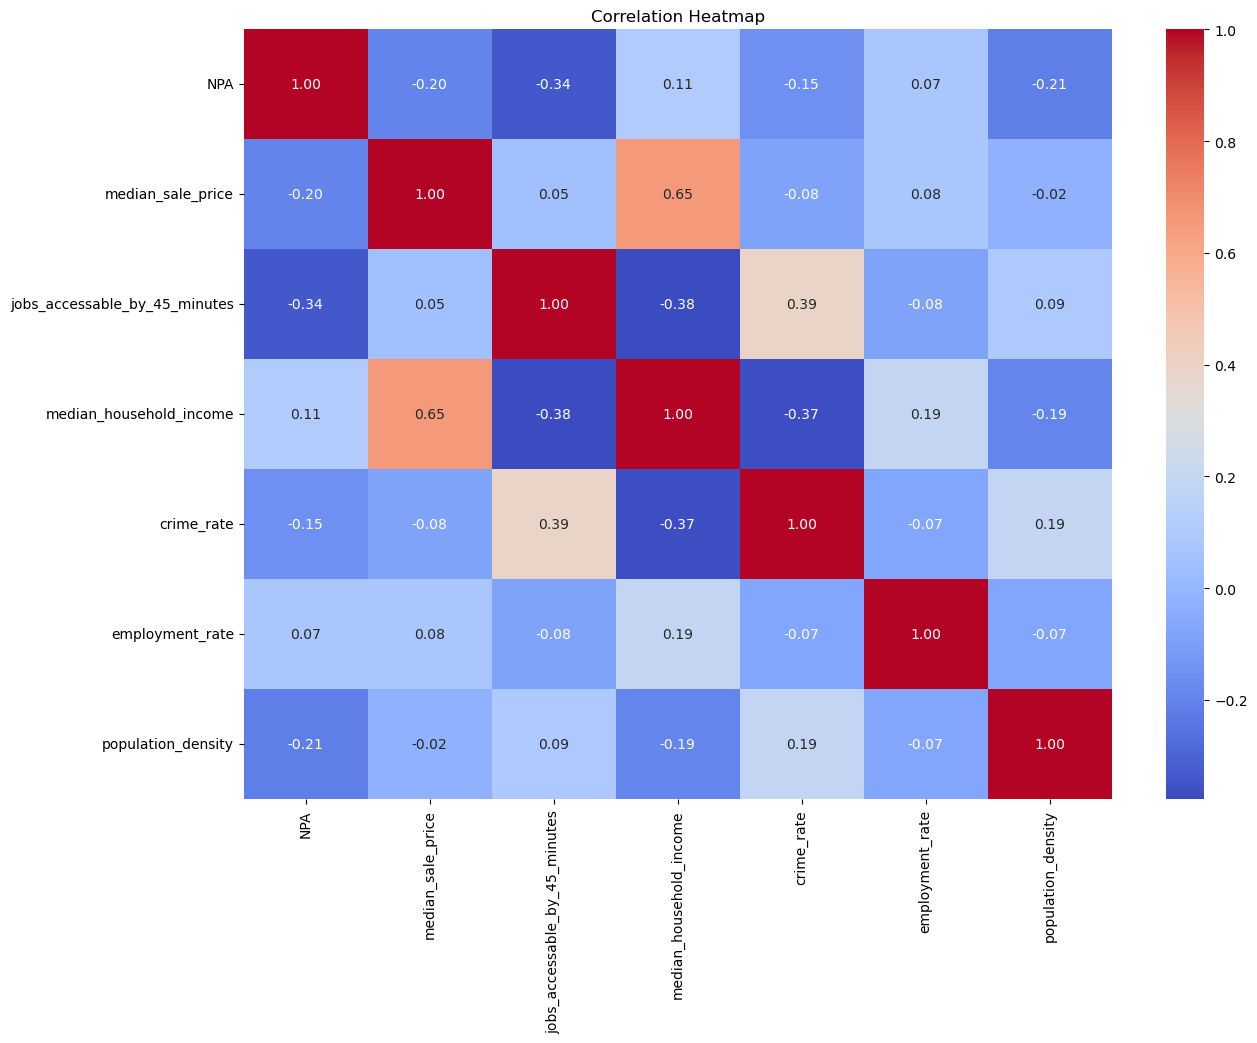

In [21]:
corr = df.corr(numeric_only=True)

# plot and show the correlation in a heatmap

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

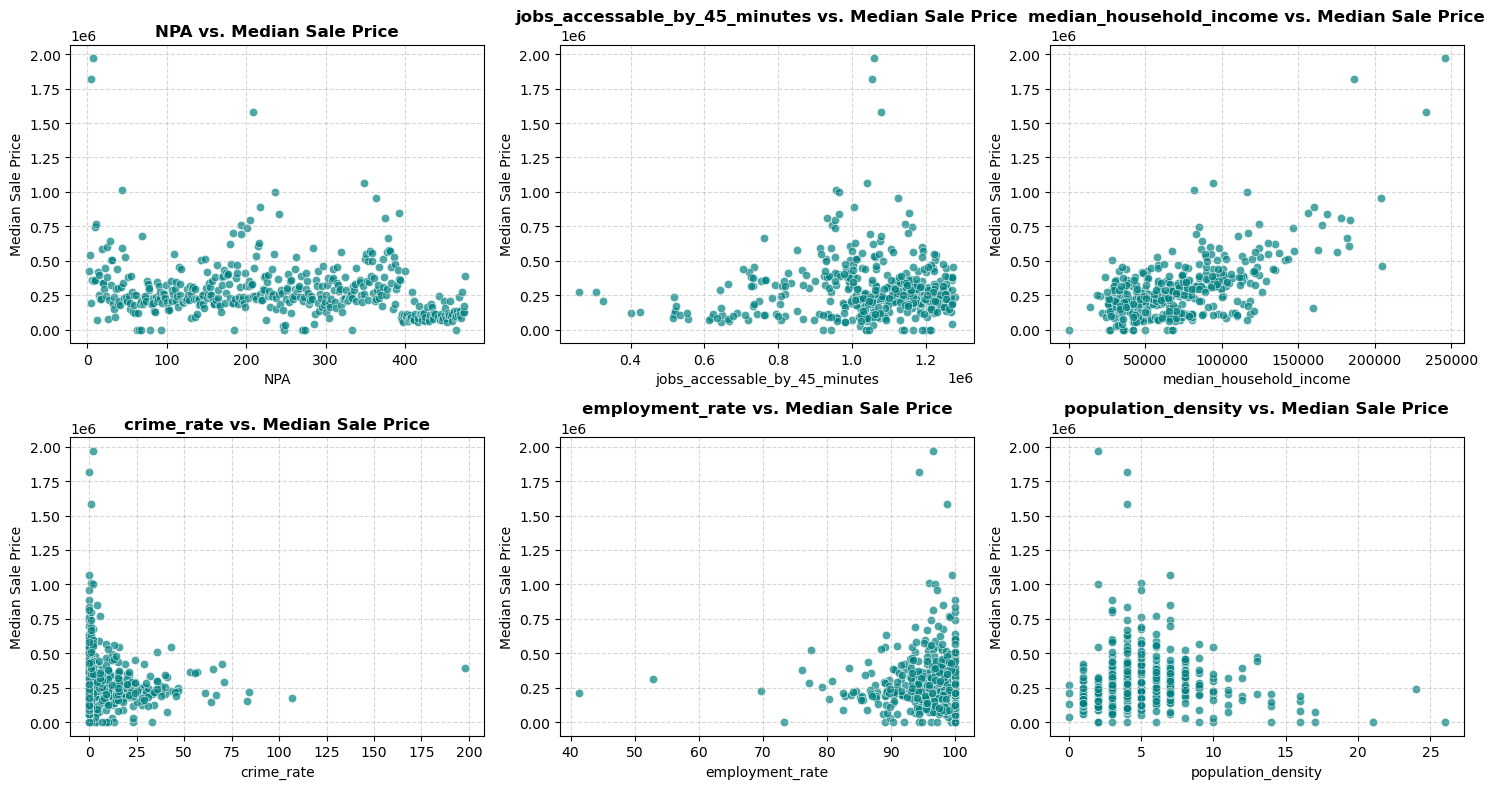

In [22]:
cols_to_plot = df.select_dtypes(include=['number']).columns.drop('median_sale_price')

# We define the layout (how many plots per row)
plots_per_row = 3
# Calculate necessary rows based on the number of features
num_rows = (len(cols_to_plot) + plots_per_row - 1) // plots_per_row

# Create the figure and subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(15, 4 * num_rows))

# Flatten axes array for easy iteration, regardless of layout
axes_flat = axes.flatten()

# Loop through each column and generate its scatterplot
for i, col in enumerate(cols_to_plot):
    # sns.scatterplot handles the plotting on the specified axis (ax=axes_flat[i])
    sns.scatterplot(data=df, x=col, y='median_sale_price', ax=axes_flat[i], color='teal', alpha=0.7)
    
    # Customizing each plot
    axes_flat[i].set_title(f'{col} vs. Median Sale Price', fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel(col, fontsize=10)
    axes_flat[i].set_ylabel('Median Sale Price', fontsize=10)
    axes_flat[i].grid(True, linestyle='--', alpha=0.5)

# Hide any empty subplots if the number of features isn't a perfect multiple
for i in range(len(cols_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[i])

# Optimize the layout spacing
plt.tight_layout()

# Display all plots at once
plt.show()

In [23]:
df['log_crime_rate']=np.log(df['crime_rate']+1)
df['log_employment_rate']=np.log(df['employment_rate']+1)
df['log_jobs_accessable_by_45_minutes']=np.log(df['jobs_accessable_by_45_minutes']+1)
df.columns

Index(['NPA', 'median_sale_price', 'jobs_accessable_by_45_minutes',
       'median_household_income', 'crime_rate', 'employment_rate',
       'population_density', 'log_crime_rate', 'log_employment_rate',
       'log_jobs_accessable_by_45_minutes'],
      dtype='str')

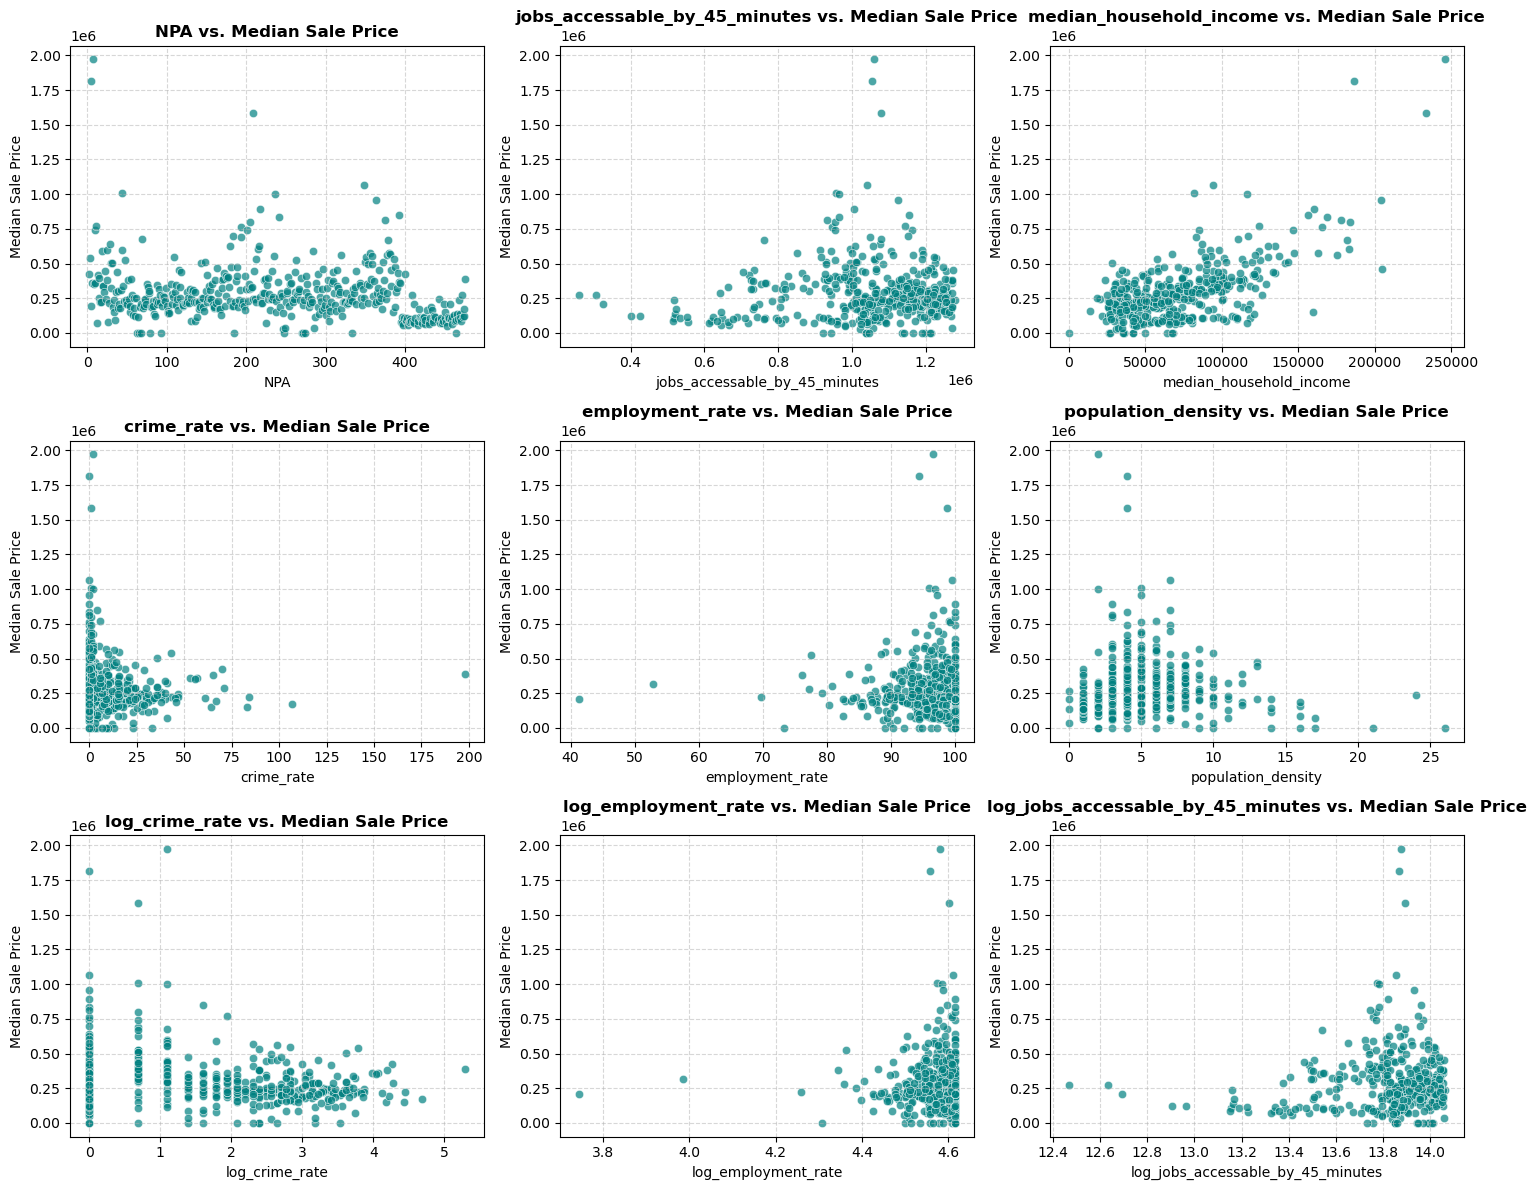

In [24]:
cols_to_plot = df.select_dtypes(include=['number']).columns.drop('median_sale_price')

# We define the layout (how many plots per row)
plots_per_row = 3
# Calculate necessary rows based on the number of features
num_rows = (len(cols_to_plot) + plots_per_row - 1) // plots_per_row

# Create the figure and subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(15, 4 * num_rows))

# Flatten axes array for easy iteration, regardless of layout
axes_flat = axes.flatten()

# Loop through each column and generate its scatterplot
for i, col in enumerate(cols_to_plot):
    # sns.scatterplot handles the plotting on the specified axis (ax=axes_flat[i])
    sns.scatterplot(data=df, x=col, y='median_sale_price', ax=axes_flat[i], color='teal', alpha=0.7)
    
    # Customizing each plot
    axes_flat[i].set_title(f'{col} vs. Median Sale Price', fontsize=12, fontweight='bold')
    axes_flat[i].set_xlabel(col, fontsize=10)
    axes_flat[i].set_ylabel('Median Sale Price', fontsize=10)
    axes_flat[i].grid(True, linestyle='--', alpha=0.5)

# Hide any empty subplots if the number of features isn't a perfect multiple
for i in range(len(cols_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[i])

# Optimize the layout spacing
plt.tight_layout()

# Display all plots at once
plt.show()

In [25]:
# selecting columns and target variable
X=df[['jobs_accessable_by_45_minutes', 'median_household_income', 'crime_rate', 'employment_rate', 'population_density']]
y = df['median_sale_price']

# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   

In [27]:
# Create a linear regression model
full_model = LinearRegression()

# Fit the model on the  data
full_model.fit(X, y)

# Make predictions on the  data
y_hat = full_model.predict(X)

# Evaluate the model
rmse = root_mean_squared_error(y, y_hat)
print('Root Mean Squared Error:', rmse)

x2 = sm.add_constant(X)

#fit linear regression model
full_model_a = sm.OLS(y, x2).fit()

#view model summary
print(full_model_a.summary())



Root Mean Squared Error: 143060.3667885444
                            OLS Regression Results                            
Dep. Variable:      median_sale_price   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     105.6
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.26e-73
Time:                        12:14:58   Log-Likelihood:                -6073.5
No. Observations:                 457   AIC:                         1.216e+04
Df Residuals:                     451   BIC:                         1.218e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
# Create a regression tree model
dtree = DecisionTreeRegressor(random_state=0)

# Train the model
dtree.fit(X_train, y_train)

# Make predictions
predictions = dtree.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Mean Squared Error: {rmse}")

Mean Squared Error: 168018.25995810048


[Text(0.7666685072931448, 0.9821428571428571, 'median_household_income <= 160051.898\nsquared_error = 43637489026.196\nsamples = 365\nvalue = 286998.904'),
 Text(0.546573905525569, 0.9464285714285714, 'median_household_income <= 82806.797\nsquared_error = 24331450451.391\nsamples = 356\nvalue = 267830.758'),
 Text(0.6566212064093568, 0.9642857142857142, 'True  '),
 Text(0.27433924613924016, 0.9107142857142857, 'crime_rate <= 0.5\nsquared_error = 10786629705.547\nsamples = 258\nvalue = 218214.729'),
 Text(0.06262244411377751, 0.875, 'jobs_accessable_by_45_minutes <= 1027640.5\nsquared_error = 3796305844.444\nsamples = 45\nvalue = 108626.667'),
 Text(0.025554553341108475, 0.8392857142857143, 'jobs_accessable_by_45_minutes <= 553895.5\nsquared_error = 830474225.0\nsamples = 20\nvalue = 82345.0'),
 Text(0.008824593959519473, 0.8035714285714286, 'median_household_income <= 58594.398\nsquared_error = 343055555.556\nsamples = 3\nvalue = 108333.333'),
 Text(0.005883062639679649, 0.767857142857

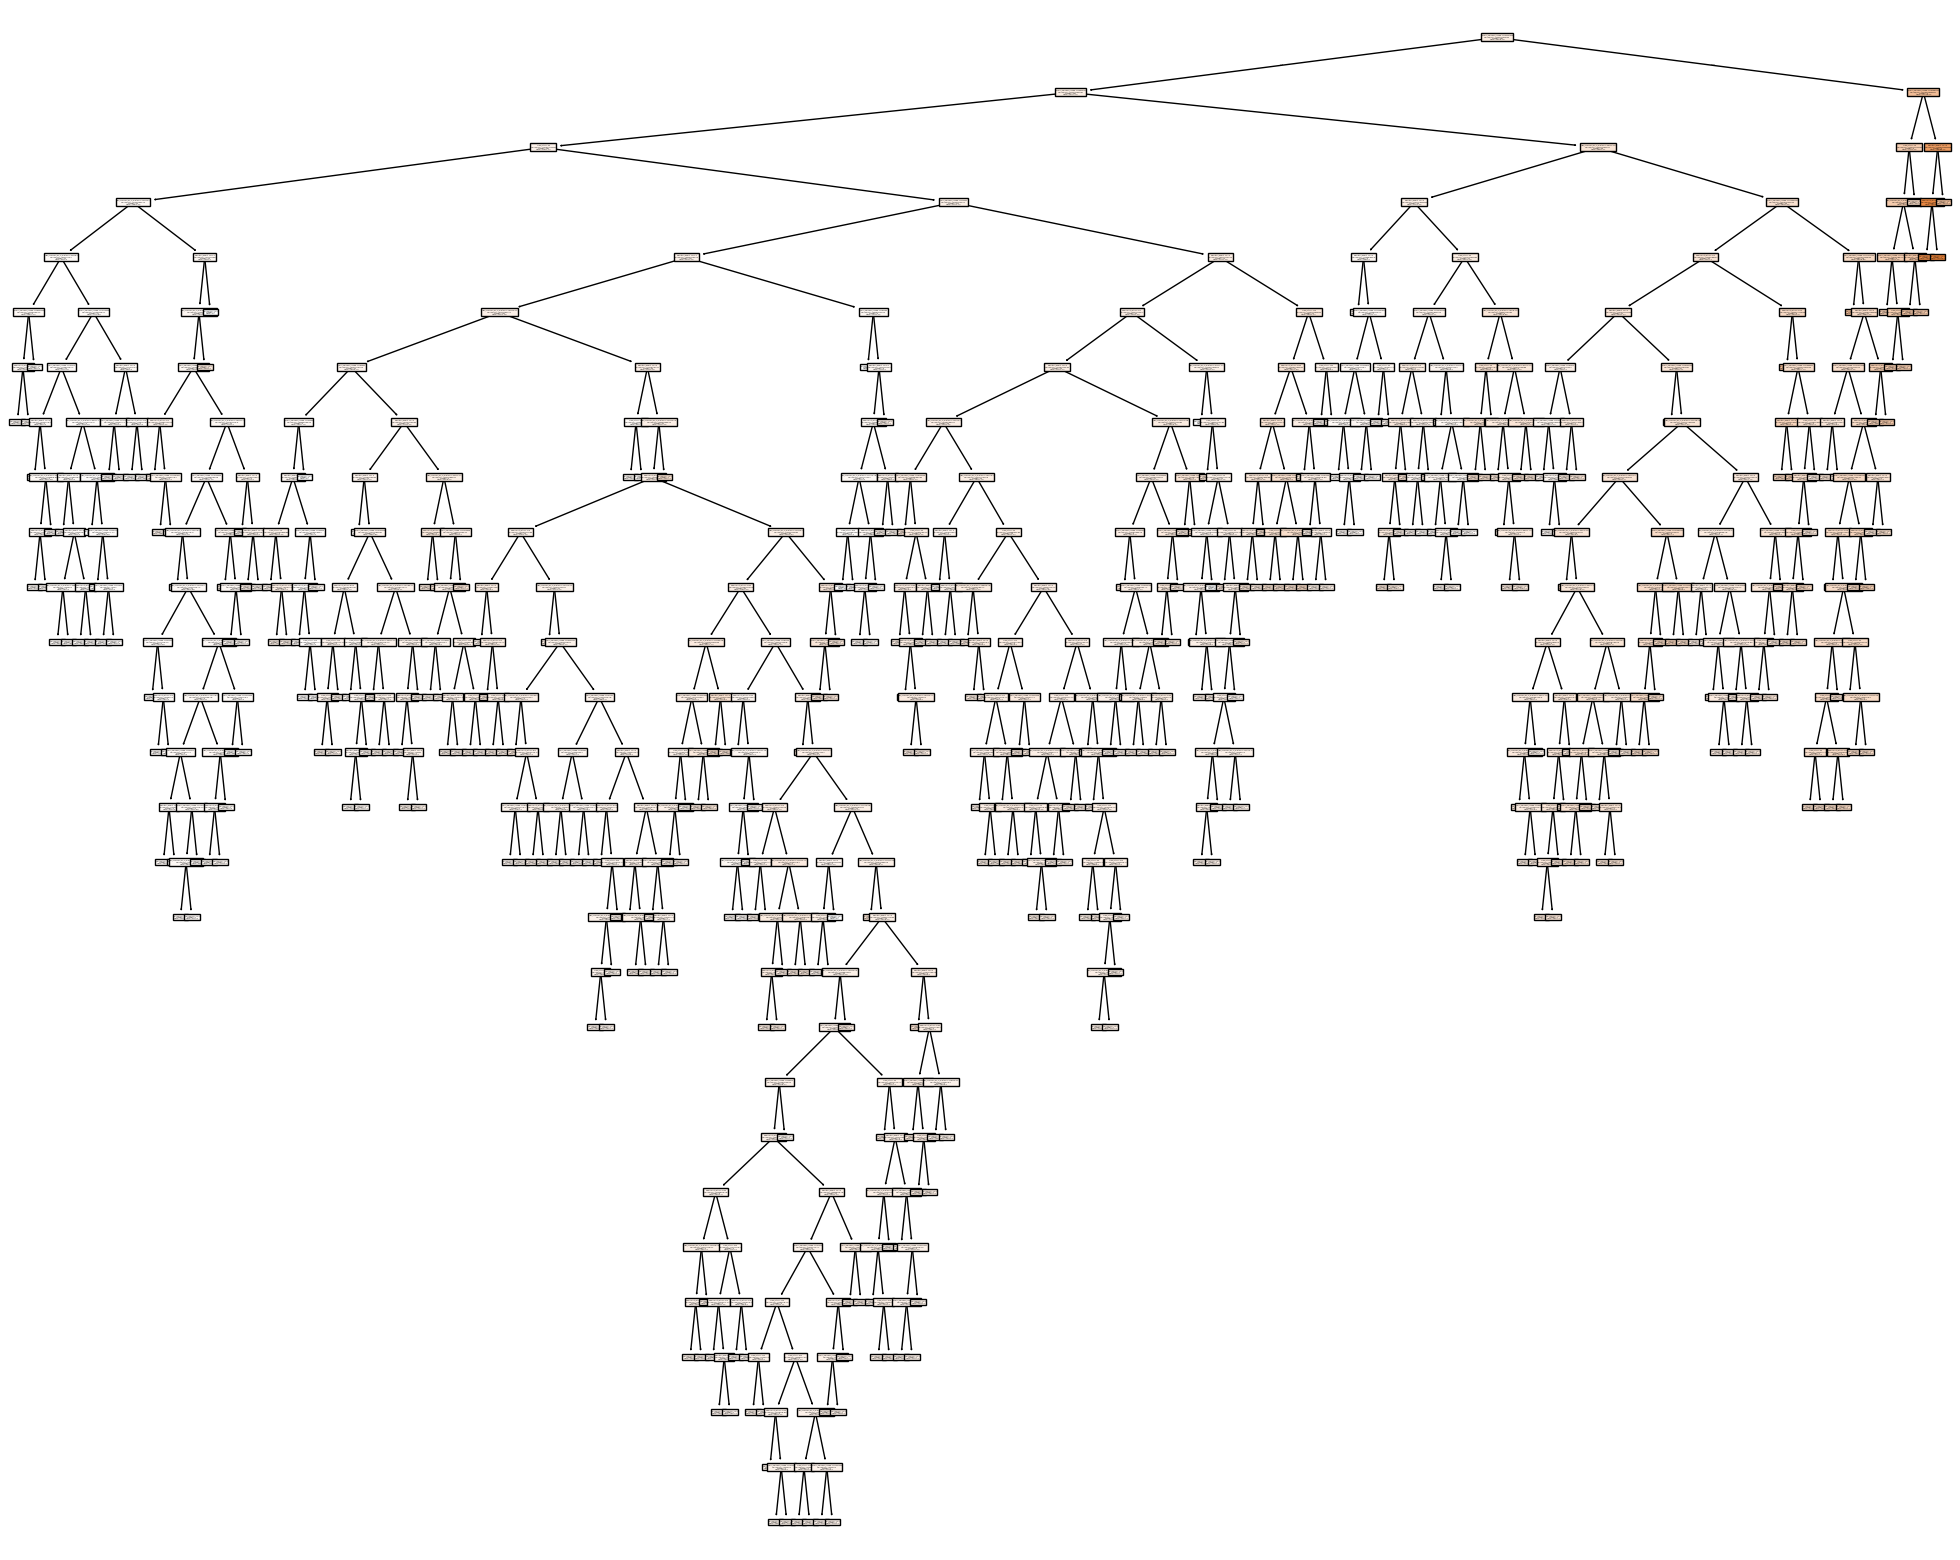

In [29]:
# create a plot of the decision tree
fig = plt.figure(figsize=(25,20))
tree.plot_tree(dtree,
                   feature_names=['jobs_accessable_by_45_minutes', 'median_household_income', 'crime_rate', 'employment_rate', 'population_density'],
                   filled=True)



Mean Squared Error: 173539.05420601275


[Text(0.7058823529411765, 0.9166666666666666, 'median_household_income <= 160051.898\nsquared_error = 43637489026.196\nsamples = 365\nvalue = 286998.904'),
 Text(0.47058823529411764, 0.75, 'median_household_income <= 82806.797\nsquared_error = 24331450451.391\nsamples = 356\nvalue = 267830.758'),
 Text(0.5882352941176471, 0.8333333333333333, 'True  '),
 Text(0.23529411764705882, 0.5833333333333334, 'crime_rate <= 0.5\nsquared_error = 10786629705.547\nsamples = 258\nvalue = 218214.729'),
 Text(0.11764705882352941, 0.4166666666666667, 'jobs_accessable_by_45_minutes <= 1027640.5\nsquared_error = 3796305844.444\nsamples = 45\nvalue = 108626.667'),
 Text(0.058823529411764705, 0.25, 'jobs_accessable_by_45_minutes <= 553895.5\nsquared_error = 830474225.0\nsamples = 20\nvalue = 82345.0'),
 Text(0.029411764705882353, 0.08333333333333333, 'squared_error = 343055555.556\nsamples = 3\nvalue = 108333.333'),
 Text(0.08823529411764706, 0.08333333333333333, 'squared_error = 776269186.851\nsamples = 17

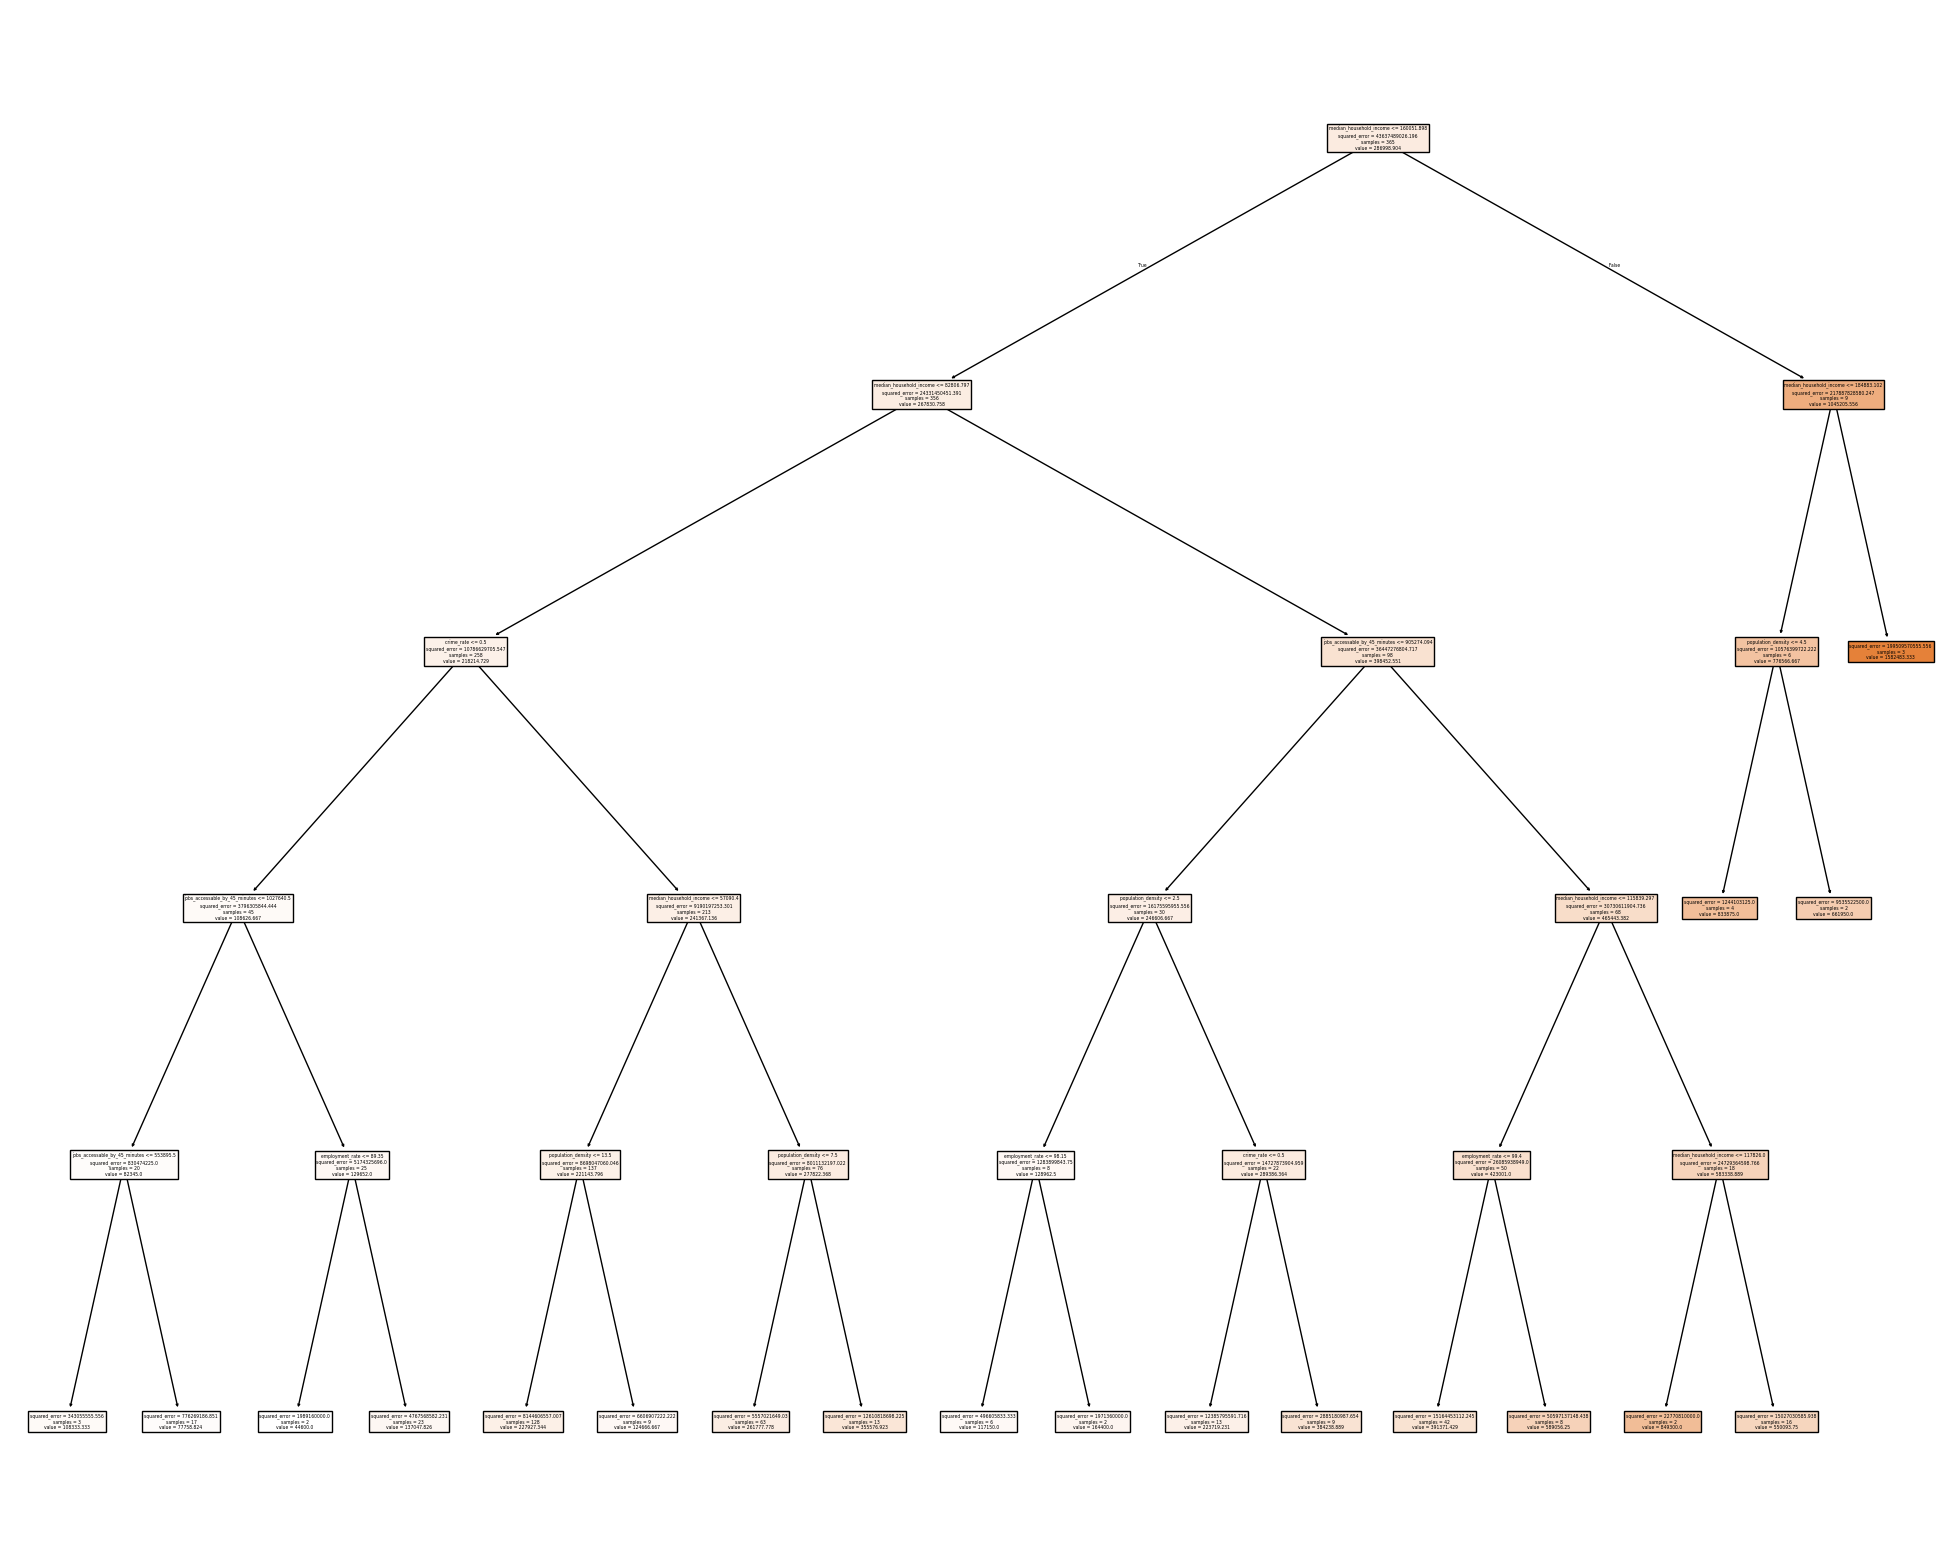

In [30]:


# initiate a decision tree with a max depth of 4
dt_pre_pruned = DecisionTreeRegressor(max_depth=5, min_samples_split=6, min_samples_leaf=2)

# Train the model
dt_pre_pruned.fit(X_train, y_train)

predictions = dt_pre_pruned.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Mean Squared Error: {rmse}")

fig = plt.figure(figsize=(25,20))
tree.plot_tree(dt_pre_pruned,
                   feature_names=['jobs_accessable_by_45_minutes', 'median_household_income', 'crime_rate', 'employment_rate', 'population_density'],
                   filled=True)




In [31]:
from pygam import (s as s_gam,
                   l as l_gam,
                   f as f_gam,
                   LinearGAM)

gam_full = LinearGAM(s_gam(0) +
                     s_gam(1, n_splines=7) +
                     f_gam(2, lam=0))
Xgam = np.column_stack([X])
gam_full = gam_full.fit(Xgam, y)

In [32]:


gam_full.summary()
     


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     37.2594
Link Function:                     IdentityLink Log Likelihood:                                 -6038.4306
Number of Samples:                          457 AIC:                                              12153.38
                                                AICc:                                           12160.5712
                                                GCV:                                      22289854140.2677
                                                Scale:                                         138001.8931
                                                Pseudo R-Squared:                                   0.6063
Feature Function                  Lam

C:\Users\Isaac\AppData\Local\Temp\ipykernel_10956\3667082475.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam_full.summary()
